# Week 9 Phase 2.2 — width-informed active learning

**Width helps prediction. Does it help us choose which simulation to run next, without cheating?**

This notebook reads the generated artifacts. The engine is `src/week9_phase2_2_width_informed_active_learning.py`.


In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
pd.set_option('display.width', 190)
pd.set_option('display.max_columns', 40)
ROOT = Path.cwd().parents[1] if Path.cwd().name == 'week_09' else Path.cwd()
OUT = ROOT / 'outputs' / 'week9_phase2_2_width_informed_active_learning'
assert OUT.is_dir(), OUT


## 1. The question, and the trap in it

Phase 2.1R showed the biggest width jump helps a model **rank** Keyhole risk. The obvious next thought is 'so let's use width to choose which simulation to run next'.

**That is where it gets easy to cheat.** At budget 16 we have queried 16 simulations. Those 16 have a revealed label and an observed width. A candidate we have *not* queried has neither — if we scored it using its true width we would be reading the answer sheet.

So the deployable rule is: learn width from `[P, VX, LS, ST]` using only the queried points, and predict it for everyone else. If the predicted max ΔW is 28 µm, the width-informed M3 uses 28. Only after we actually query that simulation does the real observed value replace the 28, and the predictor is refitted.


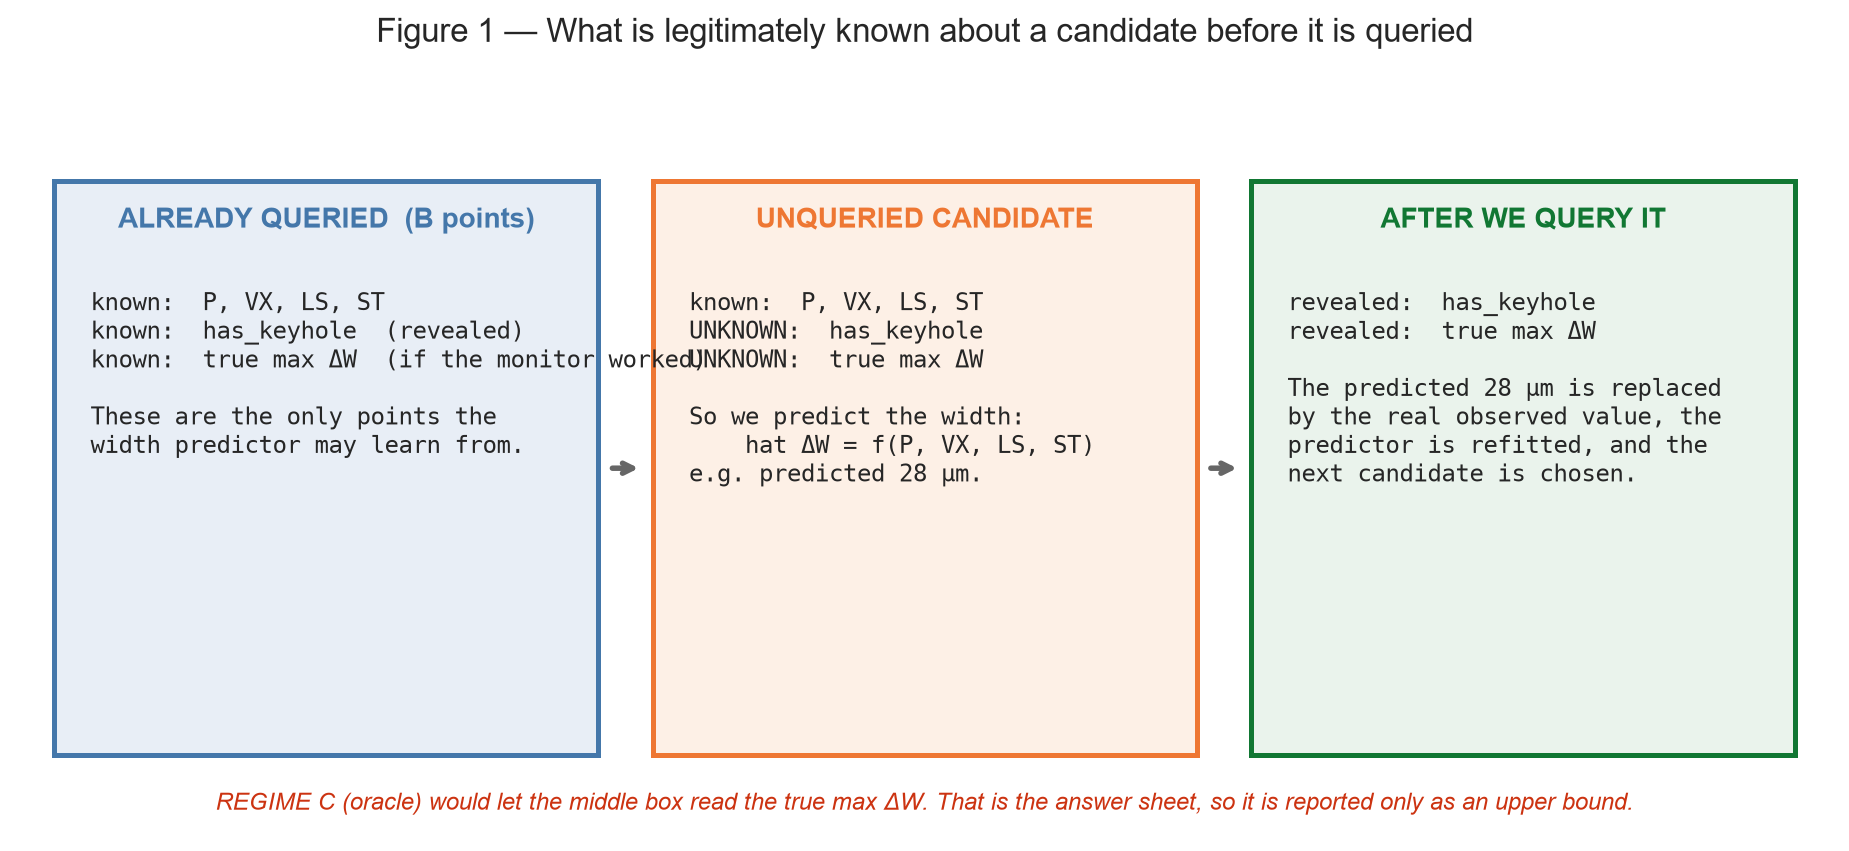

,quantity,value,note
0,population_with_usable_width,350.000000,of 405; the other 55 are treated as a failed m...
1,population_without_usable_width,55.000000,NaN
2,keyhole_rate_with_width,0.200000,"missingness is structured, so all results are ..."
3,keyhole_rate_without_width,0.054545,NaN
4,min_width_observed_in_initial_design,11.000000,over the 100 frozen 16-point designs; >0 means...
5,mean_width_observed_in_initial_design,14.240000,NaN
6,min_train_pool_width_fraction,0.848765,NaN
7,mean_train_pool_width_fraction,0.864198,NaN


In [2]:
display(Image(filename=OUT/'figures'/'01_information_available.png'))
display(pd.read_csv(OUT/'width_availability_audit.csv'))


## 2. The incumbent is re-derived, not quoted

The baseline is the current incumbent: M3 plus M3 probability margin, choosing the unqueried training-pool simulation whose predicted probability sits closest to 0.5.

Rather than copying Phase 1.14's published number, the whole trajectory is re-run here and checked against it. If the reproduction is exact, every width arm can be read on the same scale.


In [3]:
display(pd.read_csv(OUT/'phase114_reproduction_gate.csv'))


,quantity,phase114_published_P1,phase22_A0_reproduced,abs_difference,status
0,q20_accuracy_AULC_B16_40,0.826042,0.826042,0.0,PASS
1,q20_accuracy_B16,0.785882,NaN,NaN,REFERENCE
2,q20_accuracy_B40,0.846471,NaN,NaN,REFERENCE
3,q20_accuracy_B80,0.861176,NaN,NaN,REFERENCE


## 3. How good is width prediction, budget by budget?

This decides whether the deployable regime can work at all. At each budget the predictor is fitted on the queried points and scored on training-pool points it has never seen.

If R² is near zero at low budgets, the predicted width is close to a constant and cannot carry the signal that made Phase 2.1R interesting.


,budget,n_width_observations_mean,rmse_mean,mae_mean,r2_mean,spearman_true_vs_predicted_mean
65,16,14.24,7.8748,5.9462,0.0713,0.3168
73,24,21.32,7.7225,5.8011,0.0922,0.3619
81,32,28.47,7.5019,5.7106,0.1371,0.3760
89,40,35.51,7.3391,5.5993,0.1530,0.3844
109,60,54.83,6.7353,5.1708,0.2769,0.4533
129,80,73.45,6.5503,4.9833,0.3361,0.5340


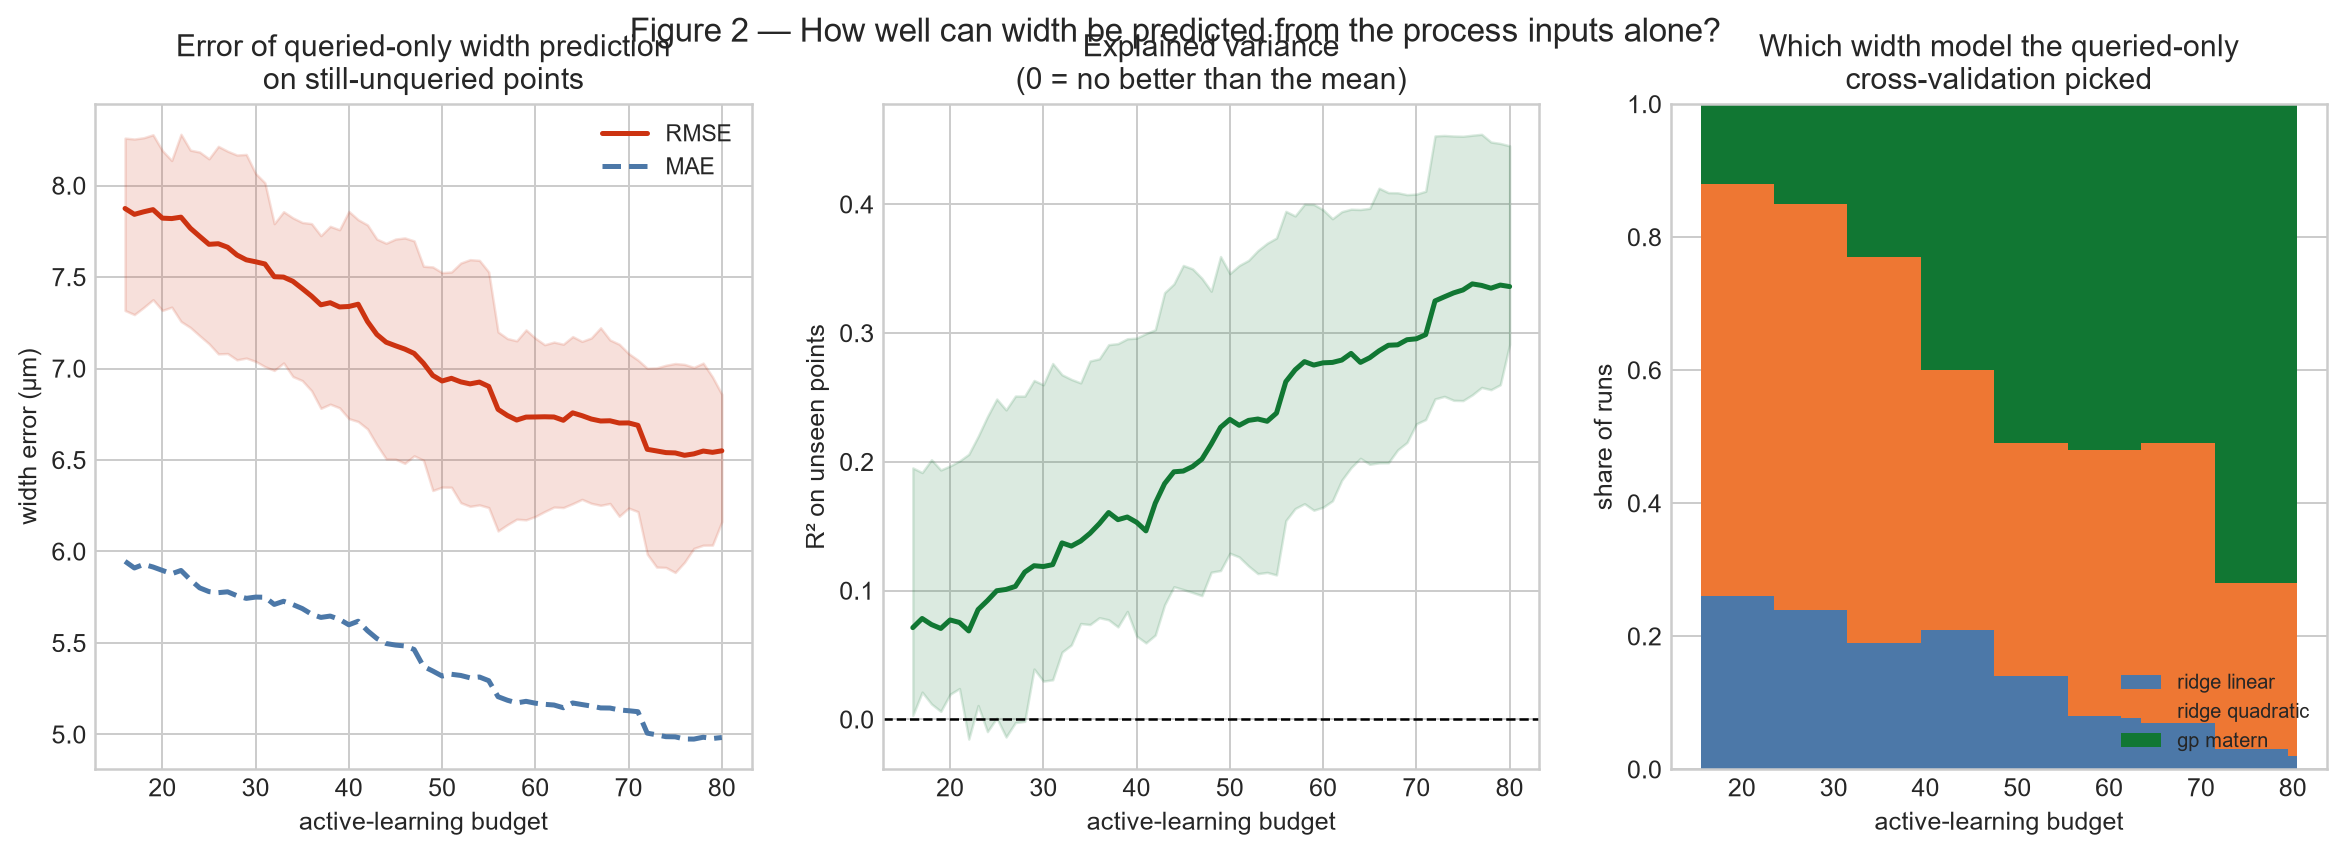

In [4]:
display(pd.read_csv(OUT/'width_predictor_diagnostics.csv').query('arm == "A1_predicted_width_margin" and budget in [16,24,32,40,60,80]')[['budget','n_width_observations_mean','rmse_mean','mae_mean','r2_mean','spearman_true_vs_predicted_mean']].round(4))
display(Image(filename=OUT/'figures'/'02_width_prediction_quality.png'))


## 4. Learning curves

Three arms on the same frozen splits and the same 16-point starts: the incumbent, the deployable predicted-width policy, and the oracle policy that is allowed to see every candidate's true width.

The oracle is **not deployable**. It is here only to say how much there was to win.


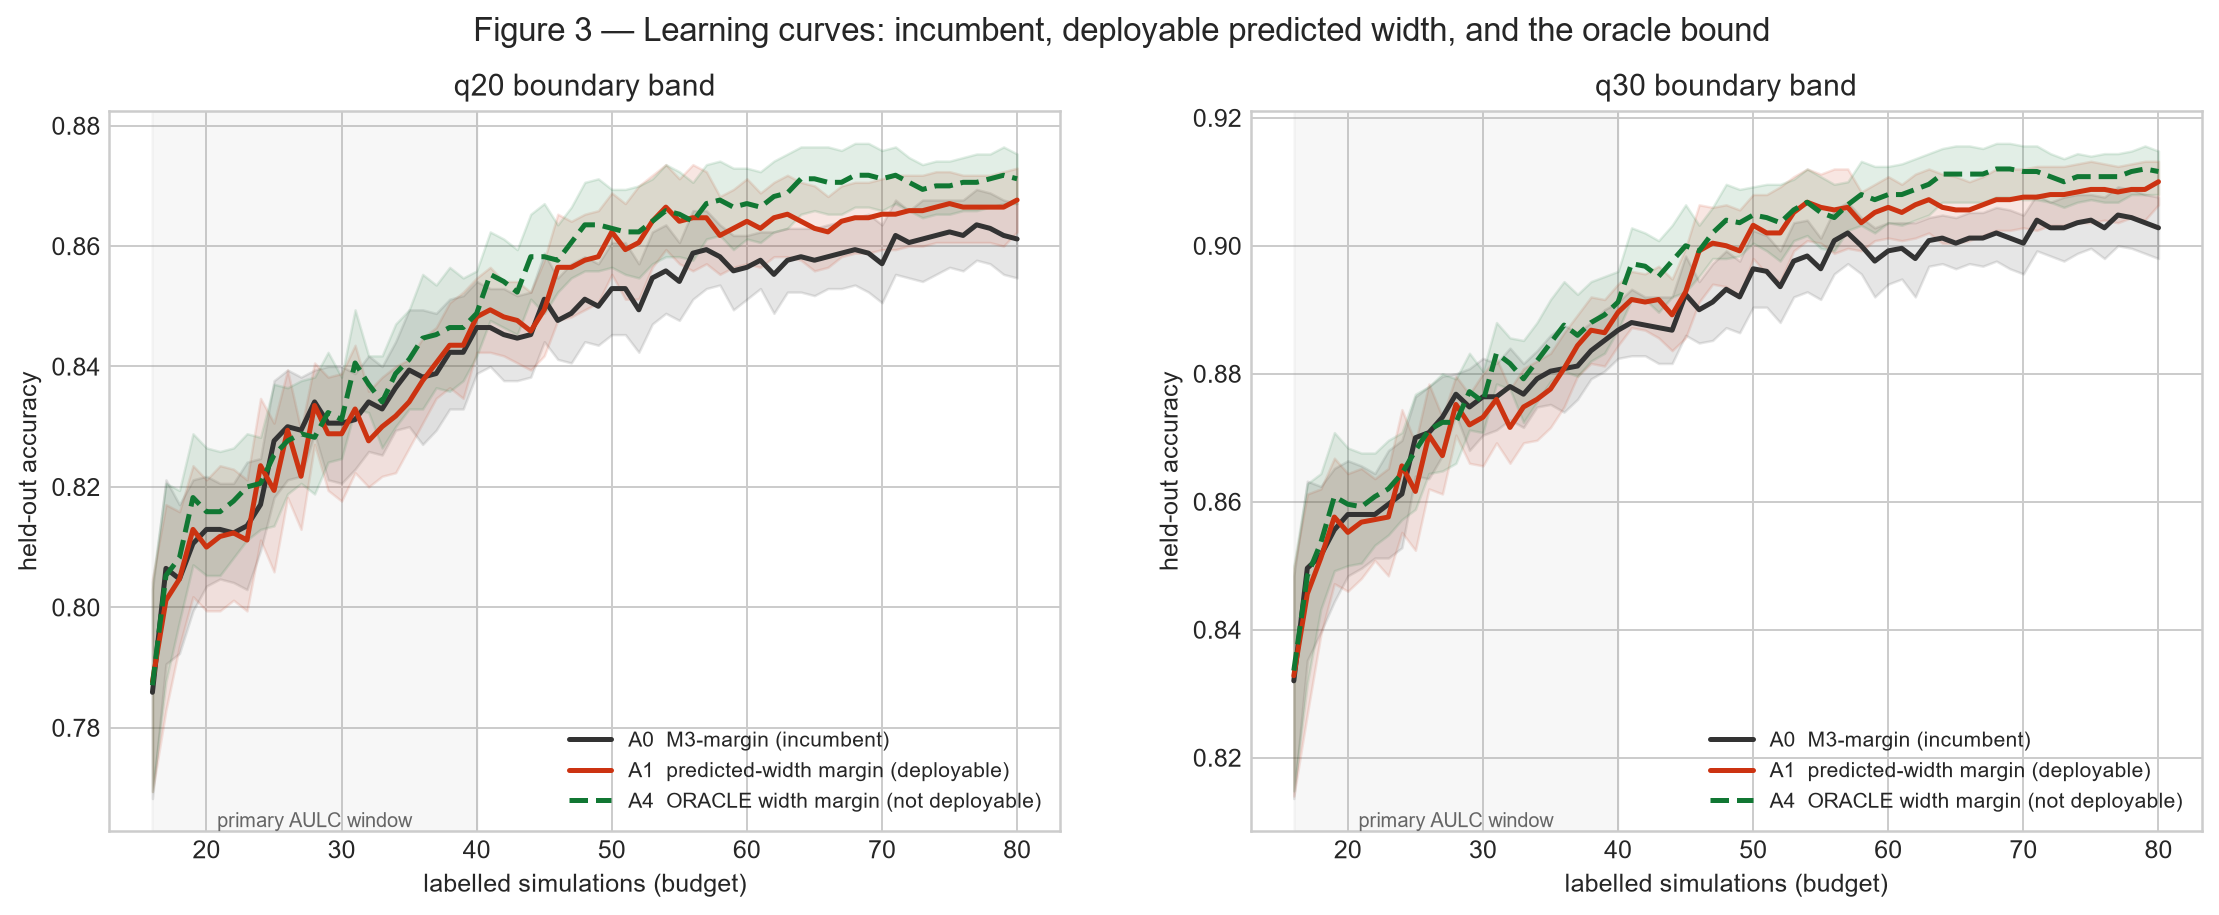

arm,A0_m3_margin,A0_model_on_A1_path,A1_model_on_A0_path,A1_predicted_width_margin,A4_model_on_A0_path,A4_oracle_width_margin
budget,,,,,,
16,0.7859,0.7859,0.7876,0.7876,0.7871,0.7871
24,0.8171,0.8229,0.8188,0.8235,0.8188,0.8206
32,0.8341,0.8294,0.8394,0.8276,0.8388,0.8371
40,0.8465,0.8459,0.8488,0.8482,0.8565,0.8488
60,0.8565,0.8553,0.8624,0.8641,0.8682,0.8671
80,0.8612,0.8606,0.8694,0.8676,0.8724,0.8712


In [5]:
display(Image(filename=OUT/'figures'/'03_learning_curves.png'))
c = pd.read_csv(OUT/'per_budget_checkpoints.csv')
display(c[(c.subset=='B1_q20') & (c.metric=='accuracy')].pivot(index='budget', columns='arm', values='mean').round(4))


## 5. The primary endpoint

One predeclared number decides this phase: **q20 accuracy AULC over budgets 16–40**, deployable arm minus incumbent. The success bar was set in advance at +0.010 with a paired 95% lower bound above zero.


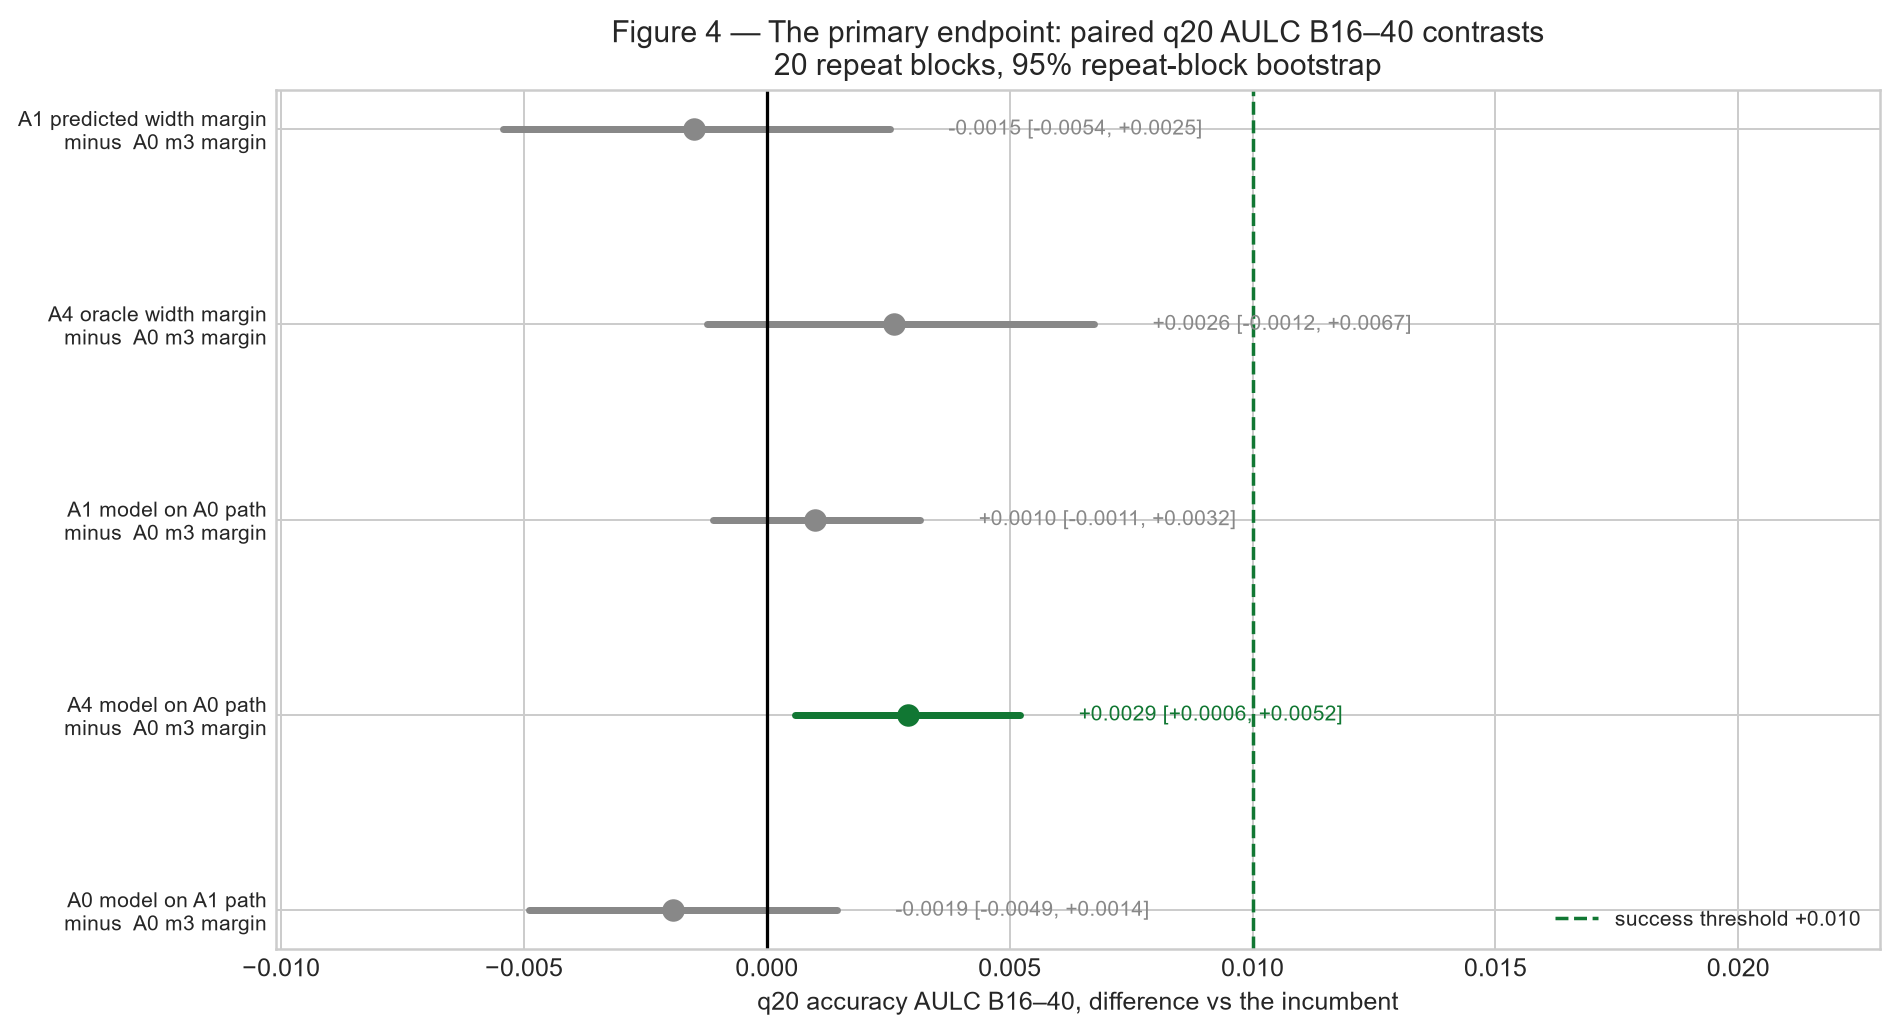

,contrast,mean_difference,ci_lower,ci_upper
0,A1_predicted_width_margin - A0_m3_margin,-0.00150,-0.00543,0.00254
42,A4_oracle_width_margin - A0_m3_margin,0.00262,-0.00124,0.00674
84,A1_model_on_A0_path - A0_m3_margin,0.00099,-0.00112,0.00316
126,A4_model_on_A0_path - A0_m3_margin,0.00290,0.00058,0.00522
168,A0_model_on_A1_path - A0_m3_margin,-0.00192,-0.00490,0.00145


In [6]:
display(Image(filename=OUT/'figures'/'04_primary_aulc_contrasts.png'))
k = pd.read_csv(OUT/'paired_aulc_contrasts.csv')
display(k[(k.subset=='B1_q20') & (k.region=='EARLY_B16_40') & (k.metric=='accuracy')][['contrast','mean_difference','ci_lower','ci_upper']].round(5))


## 6. Model value or acquisition value?

A better model is not a better acquisition rule. To separate them, the width-informed model is also scored on the **incumbent's** query path: any gain there is model value, because the queries are identical. Whatever is left over is what the changed queries bought.


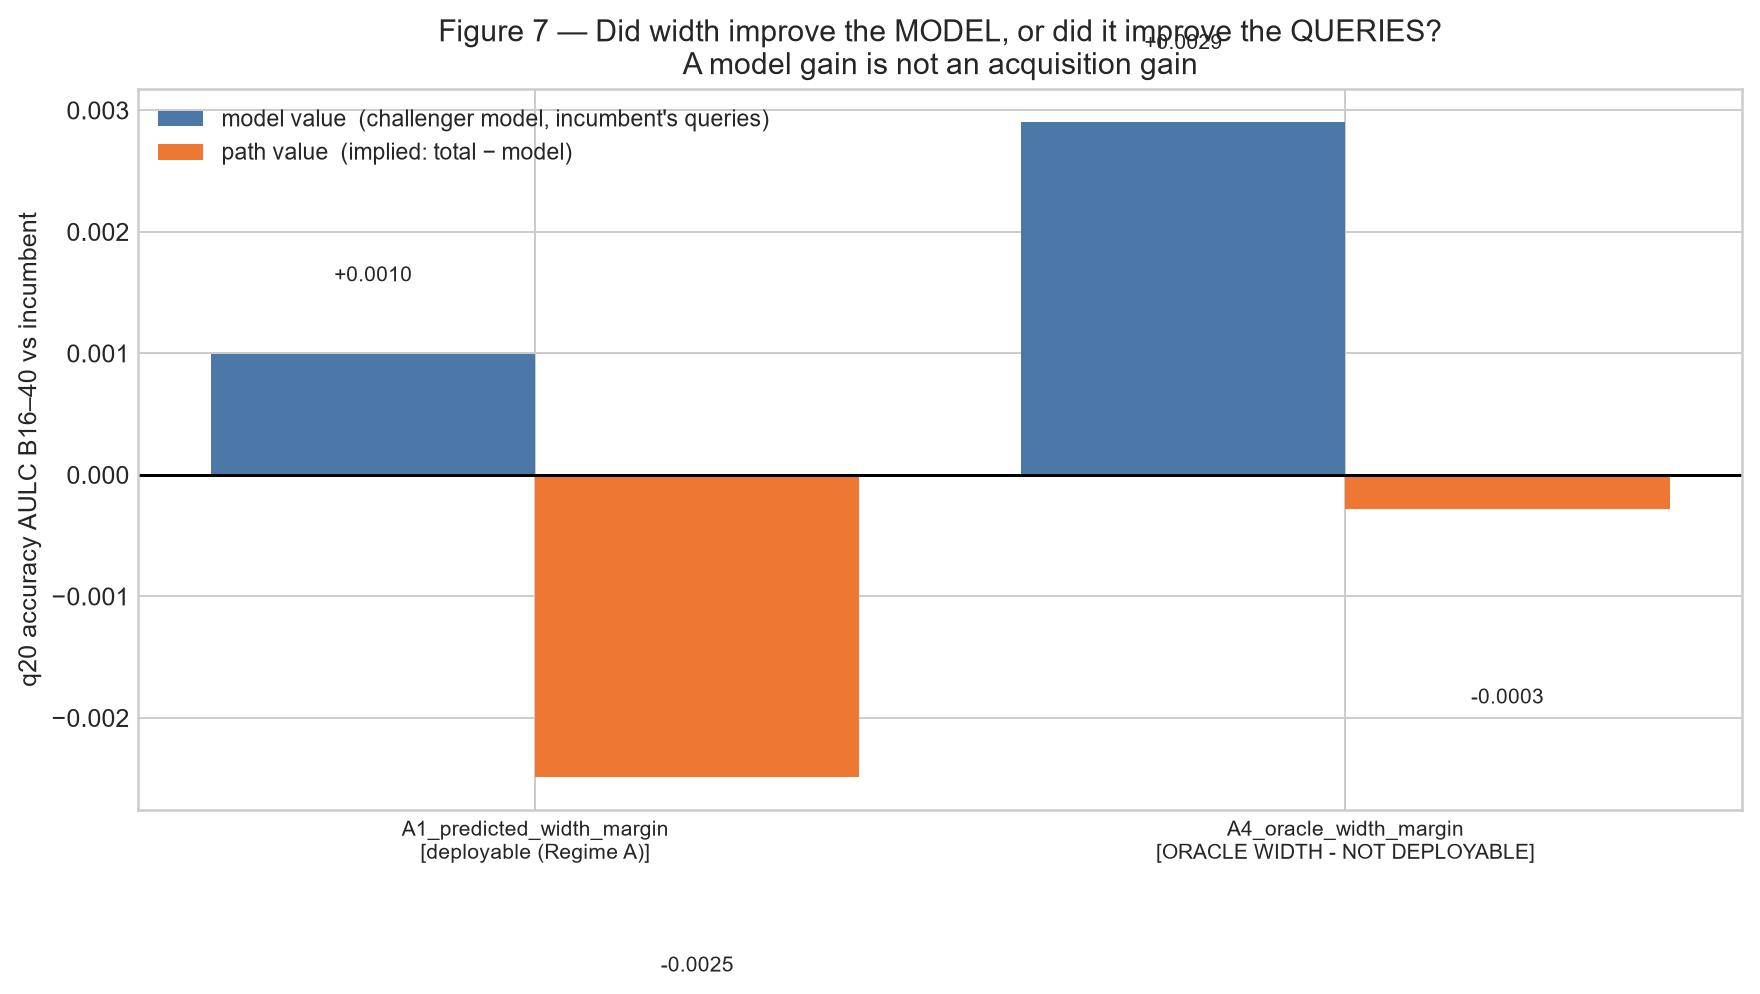

,arm,regime,model_value_same_path,path_value_implied,total_value_own_path
0,A1_predicted_width_margin,deployable (Regime A),0.00099,-0.00249,-0.00150
42,A4_oracle_width_margin,ORACLE WIDTH - NOT DEPLOYABLE,0.00290,-0.00028,0.00262


In [7]:
display(Image(filename=OUT/'figures'/'07_same_path_decomposition.png'))
display(pd.read_csv(OUT/'same_path_decomposition.csv').query('subset == "B1_q20" and region == "EARLY_B16_40" and metric == "accuracy"')[['arm','regime','model_value_same_path','path_value_implied','total_value_own_path']].round(5))


## 7. How much was there to win? (ORACLE — NOT DEPLOYABLE)

If even an oracle that knows every candidate's true width cannot beat the incumbent, then width cannot help acquisition however well we predict it, and the direction should be killed rather than tuned.


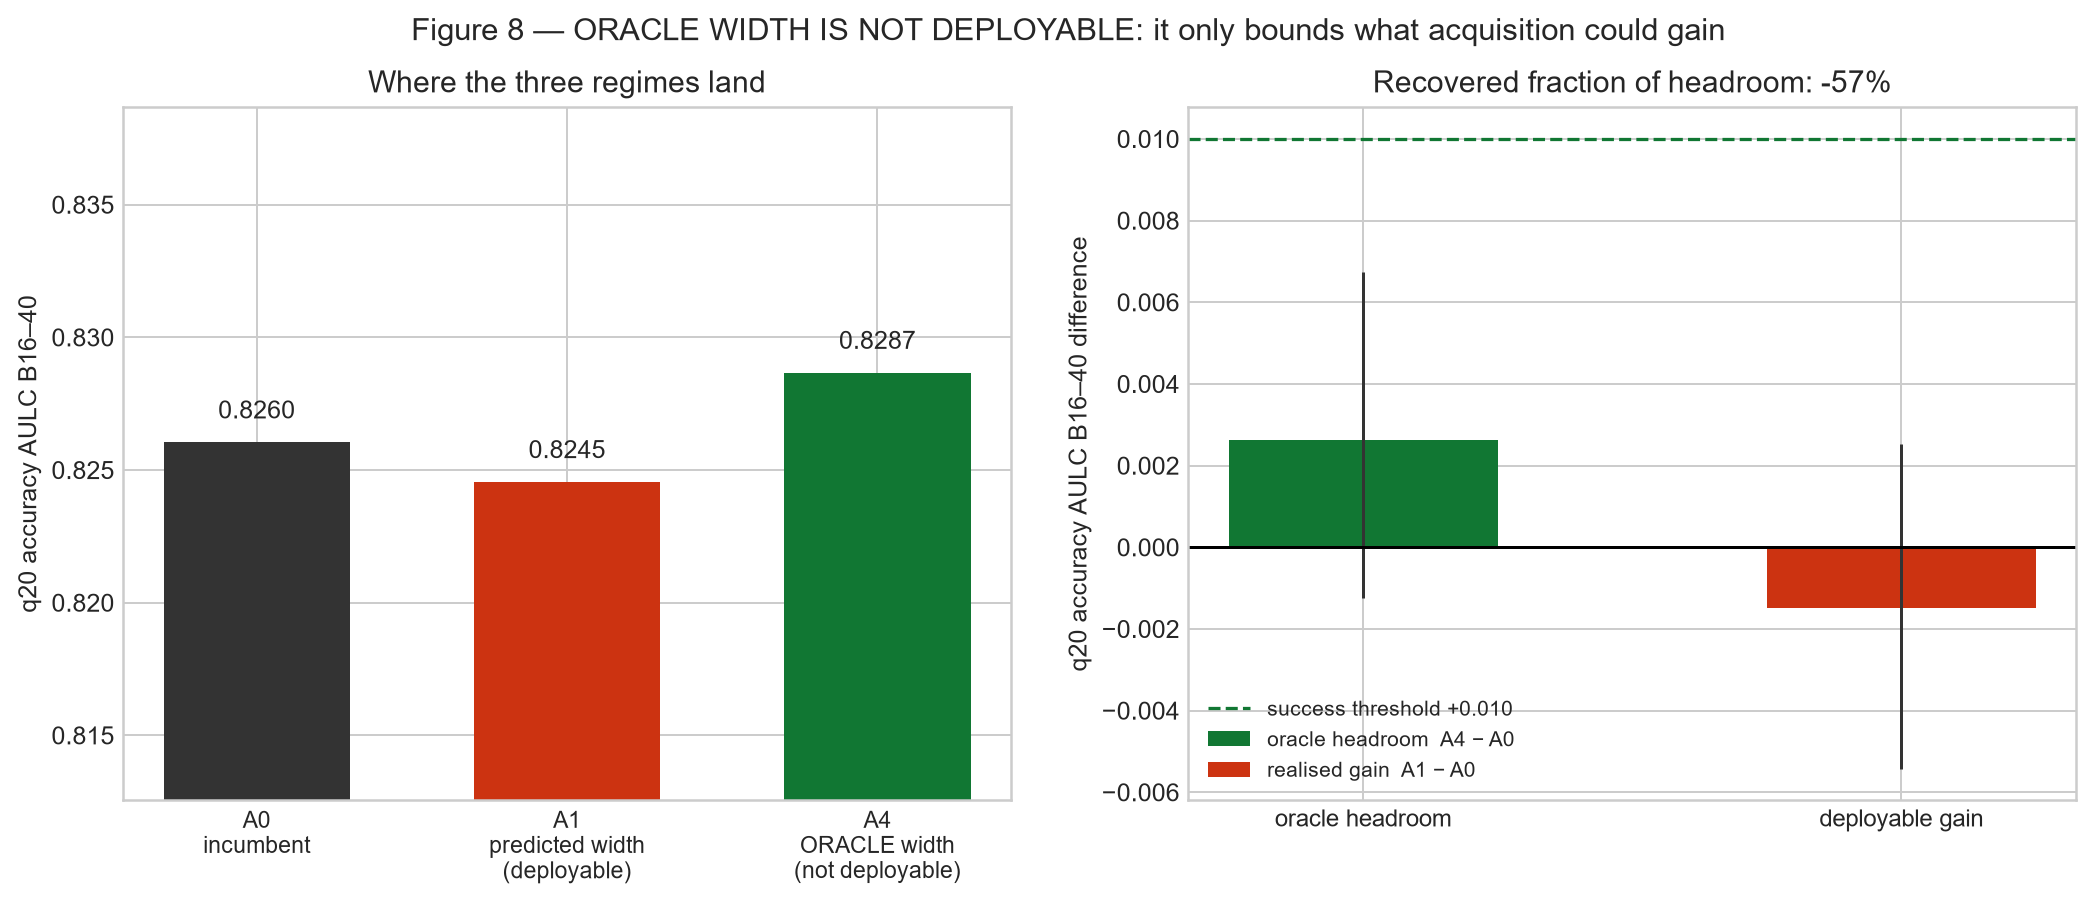

,0
subset,B1_q20
region,EARLY_B16_40
metric,accuracy
A0_incumbent,0.826042
A1_predicted_width,0.824547
A4_oracle_width,0.828664
oracle_headroom_A4_minus_A0,0.002623
oracle_headroom_ci_lower,-0.001238
oracle_headroom_ci_upper,0.006741
realised_gain_A1_minus_A0,-0.001495


In [8]:
display(Image(filename=OUT/'figures'/'08_oracle_headroom.png'))
display(pd.read_csv(OUT/'oracle_gap_decomposition.csv').query('subset == "B1_q20" and region == "EARLY_B16_40" and metric == "accuracy"').T)


## 8. Did the queries actually change?

If the width-informed policy picks essentially the same simulations as the incumbent, there is no acquisition story to tell regardless of the metrics.


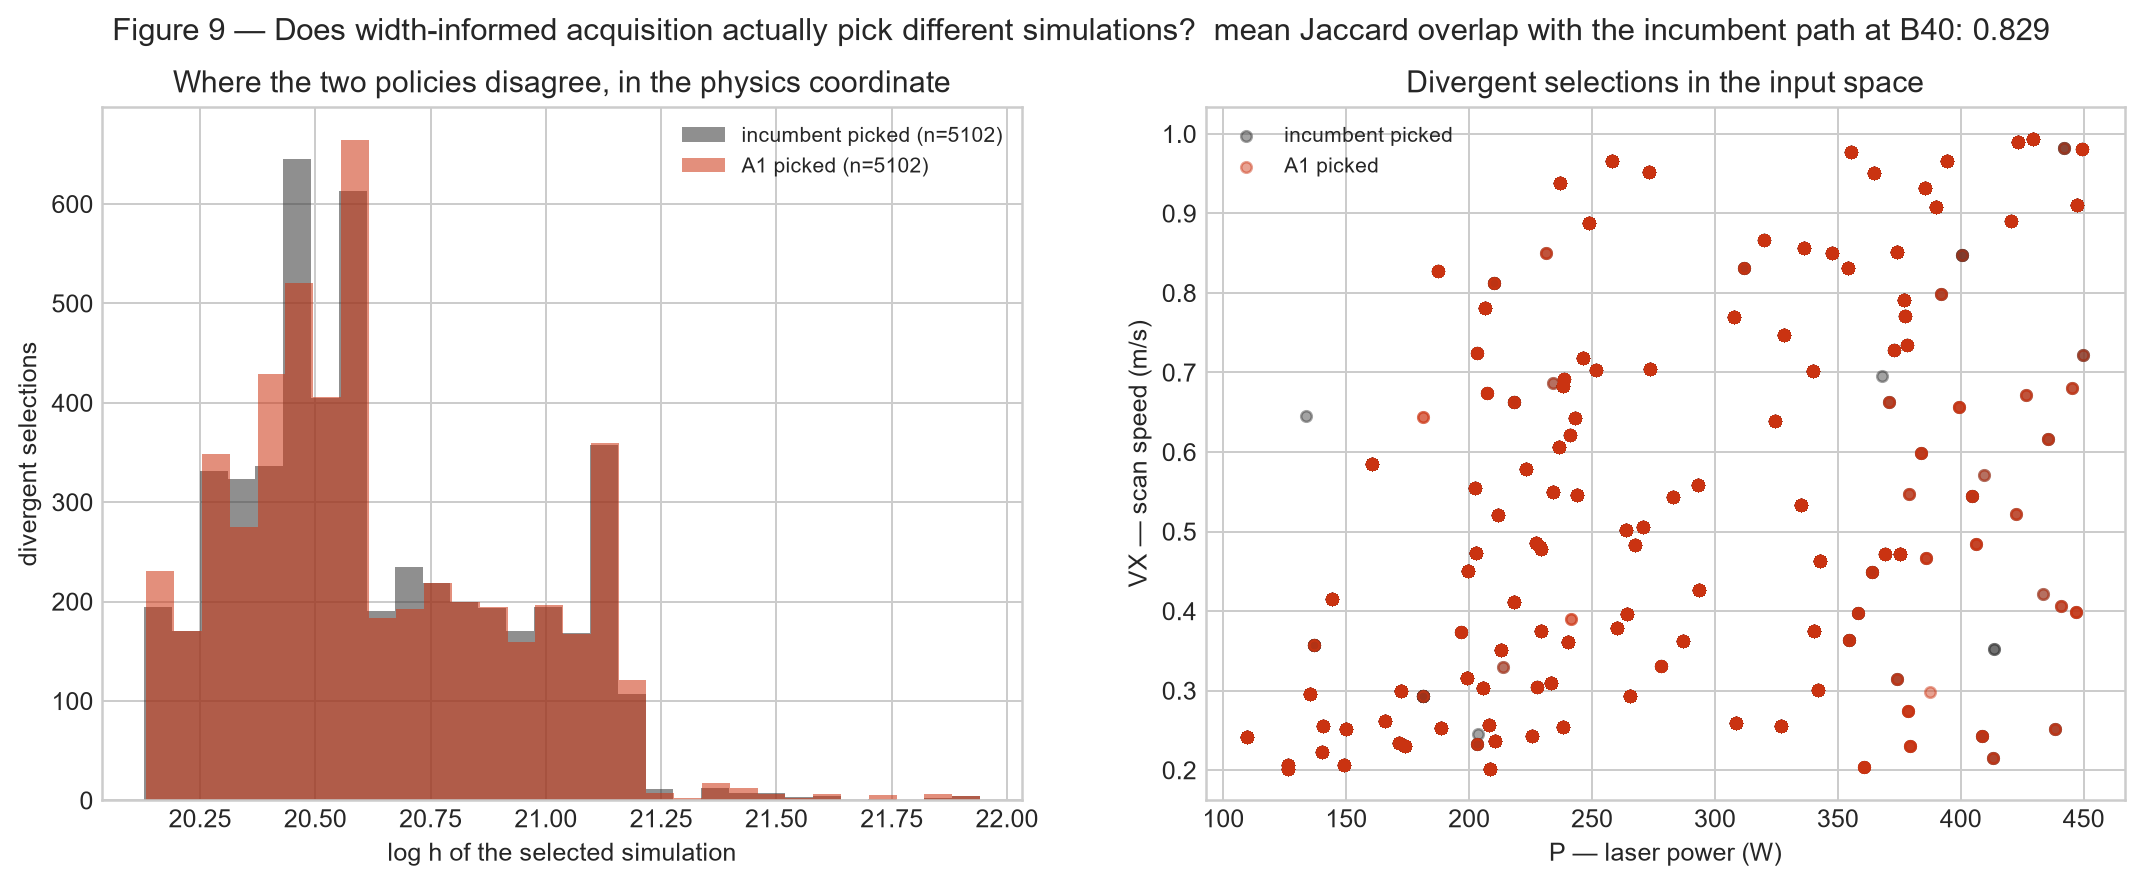

,arm,budget,mean_jaccard,median_jaccard,fraction_of_runs_differing,median_first_divergence_budget
0,A0_model_on_A1_path,16,1.0000,1.0000,0.00,NaN
1,A0_model_on_A1_path,24,0.8338,0.8462,0.69,NaN
2,A0_model_on_A1_path,32,0.8008,0.8032,0.78,NaN
3,A0_model_on_A1_path,40,0.8291,0.8605,0.95,NaN
4,A0_model_on_A1_path,60,0.9218,0.9355,0.89,NaN
5,A0_model_on_A1_path,80,0.9389,0.9512,0.94,NaN
6,A1_model_on_A0_path,16,1.0000,1.0000,0.00,NaN
7,A1_model_on_A0_path,24,1.0000,1.0000,0.00,NaN
8,A1_model_on_A0_path,32,1.0000,1.0000,0.00,NaN
9,A1_model_on_A0_path,40,1.0000,1.0000,0.00,NaN


In [9]:
display(Image(filename=OUT/'figures'/'09_divergent_queries.png'))
display(pd.read_csv(OUT/'query_path_summary.csv').round(4))


## 9. Per-budget secondary metrics

Balanced accuracy and PR-AUC across the trajectory, so a gain in one metric cannot be quoted without showing the others.


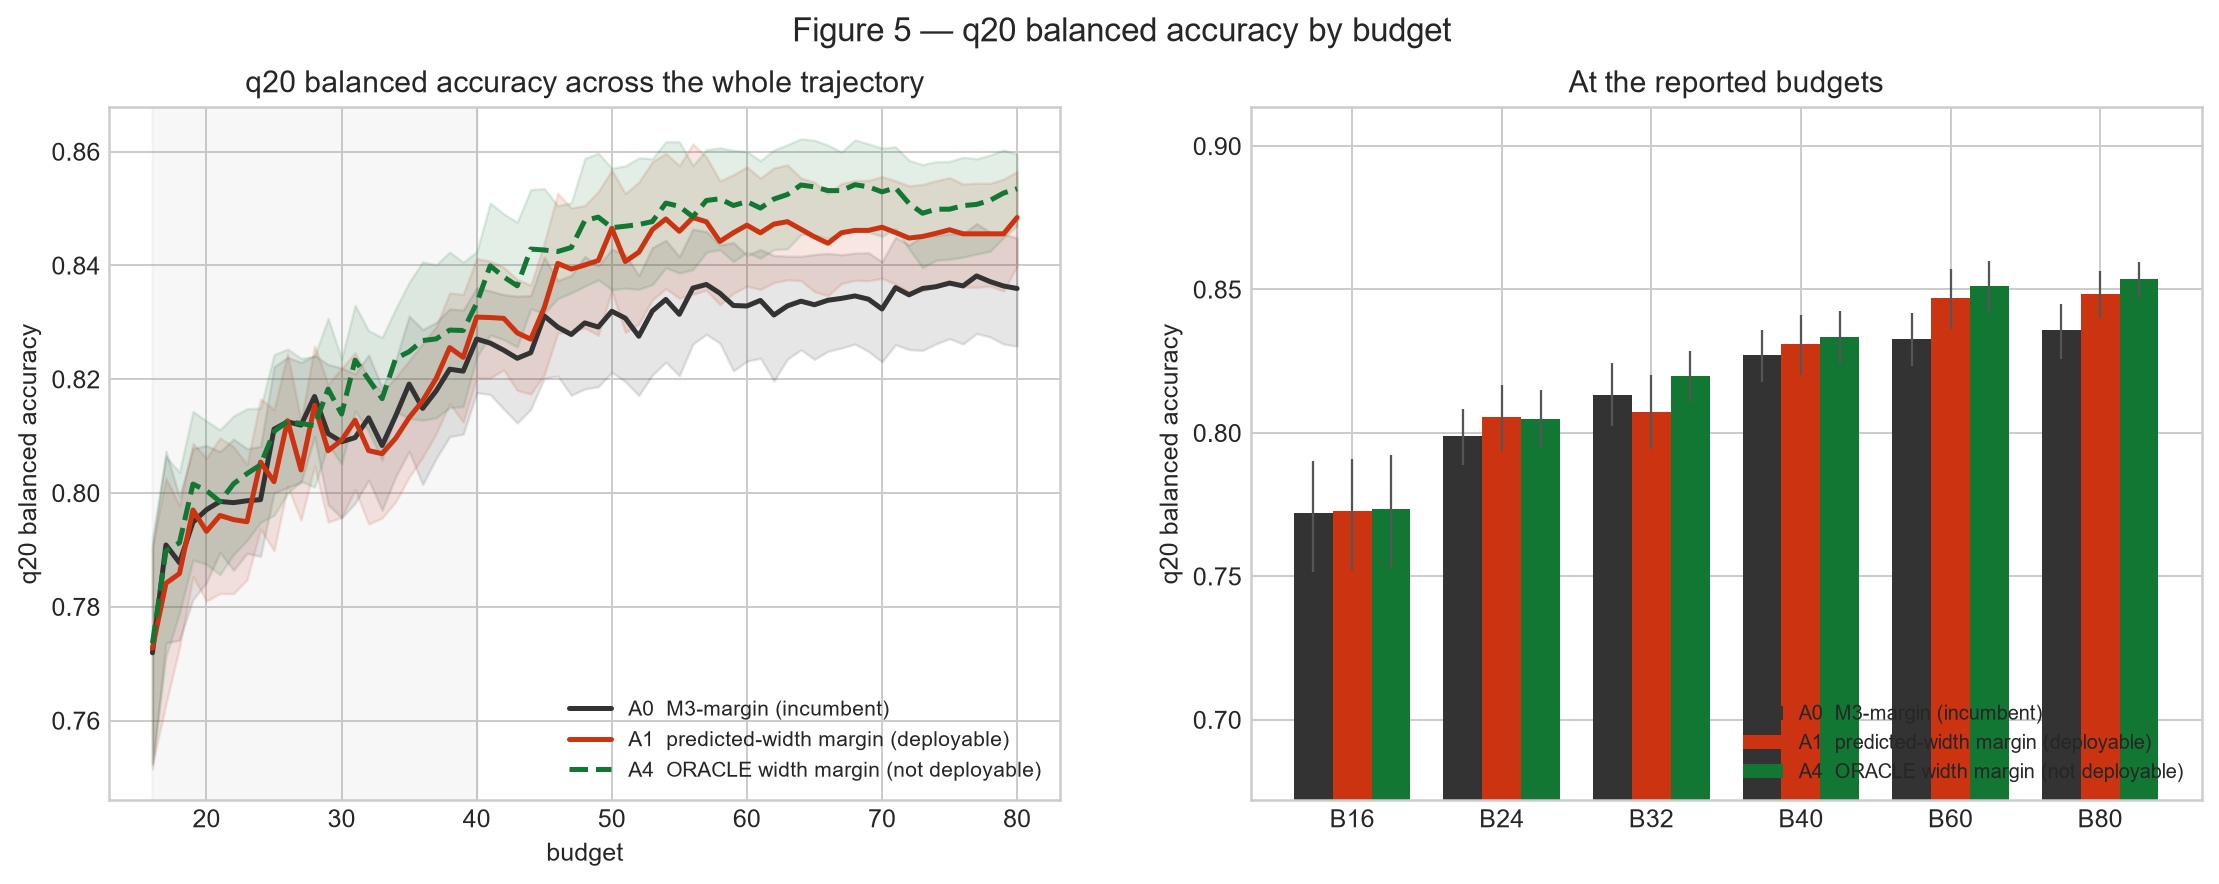

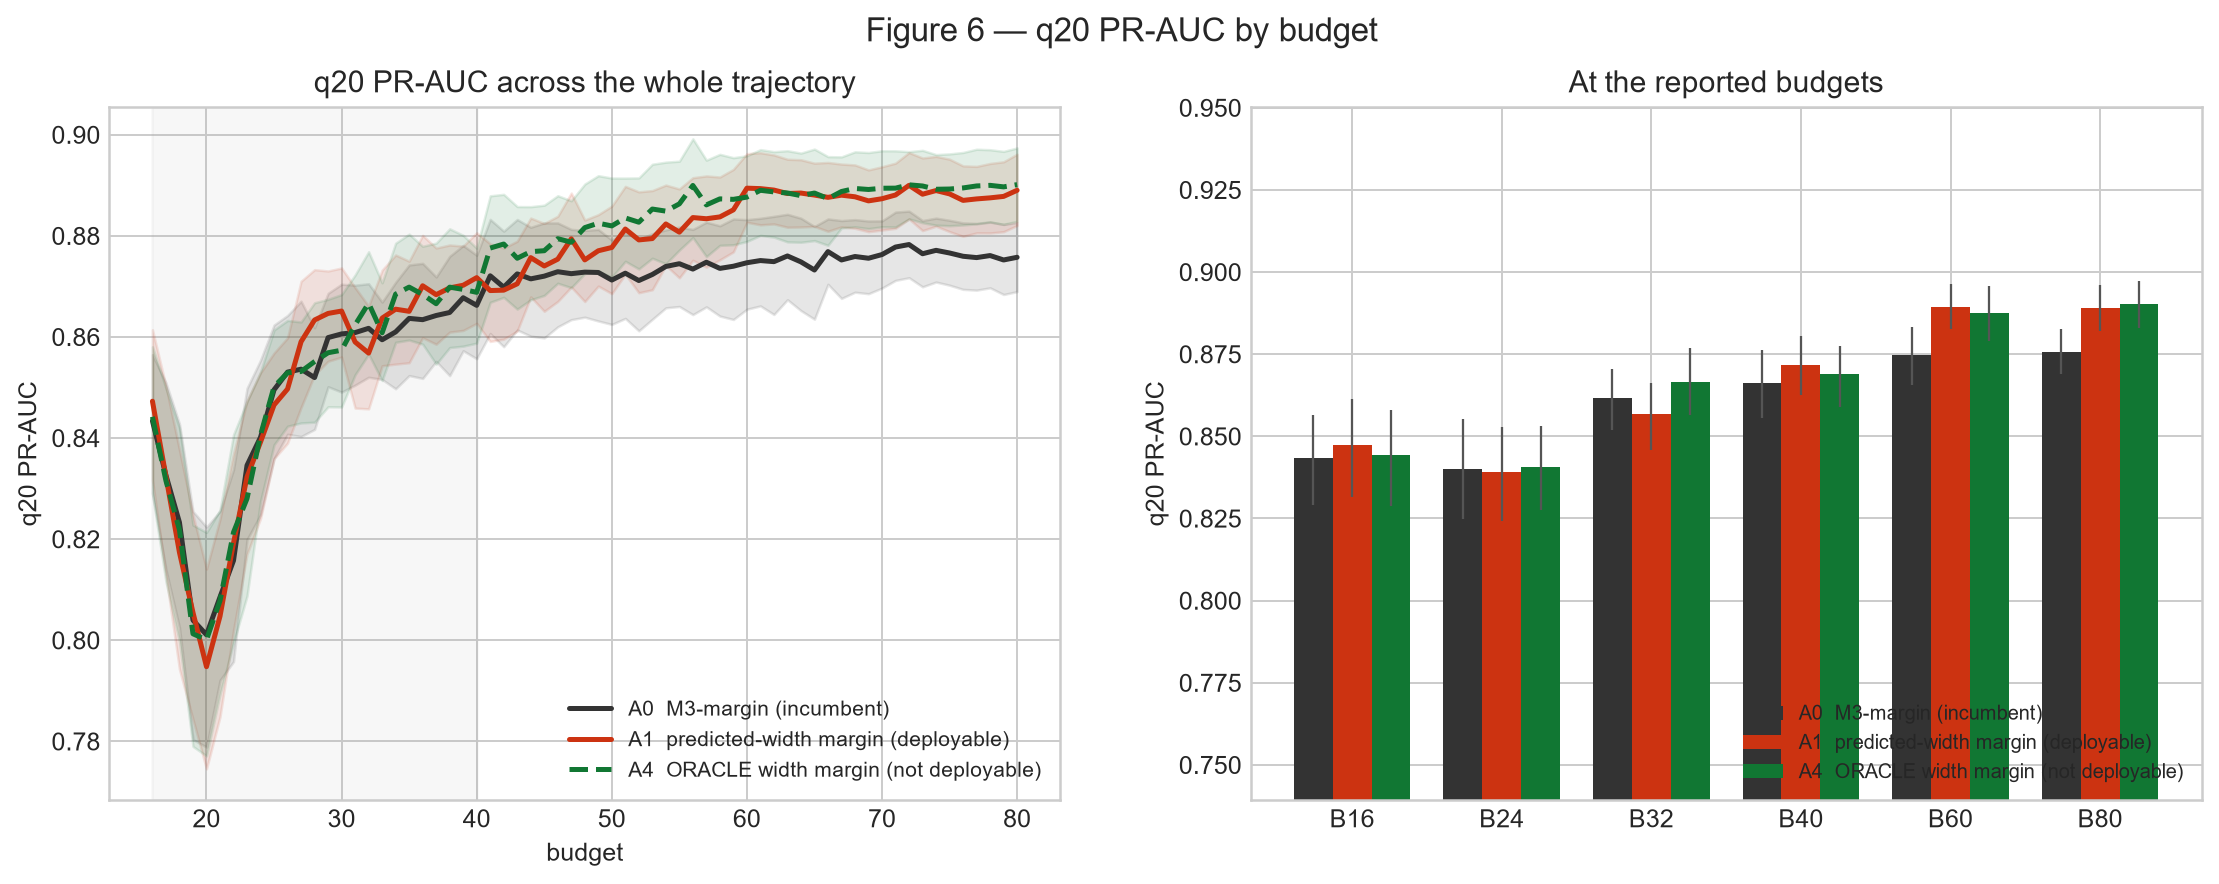

In [10]:
display(Image(filename=OUT/'figures'/'05_per_budget_q20_balanced_accuracy.png'))
display(Image(filename=OUT/'figures'/'06_per_budget_q20_pr_auc.png'))


## 10. Verdict

The predeclared verdict for this phase is **KILLED**.

The claim ledger is the contract; the guardrails say what each status is allowed to mean.


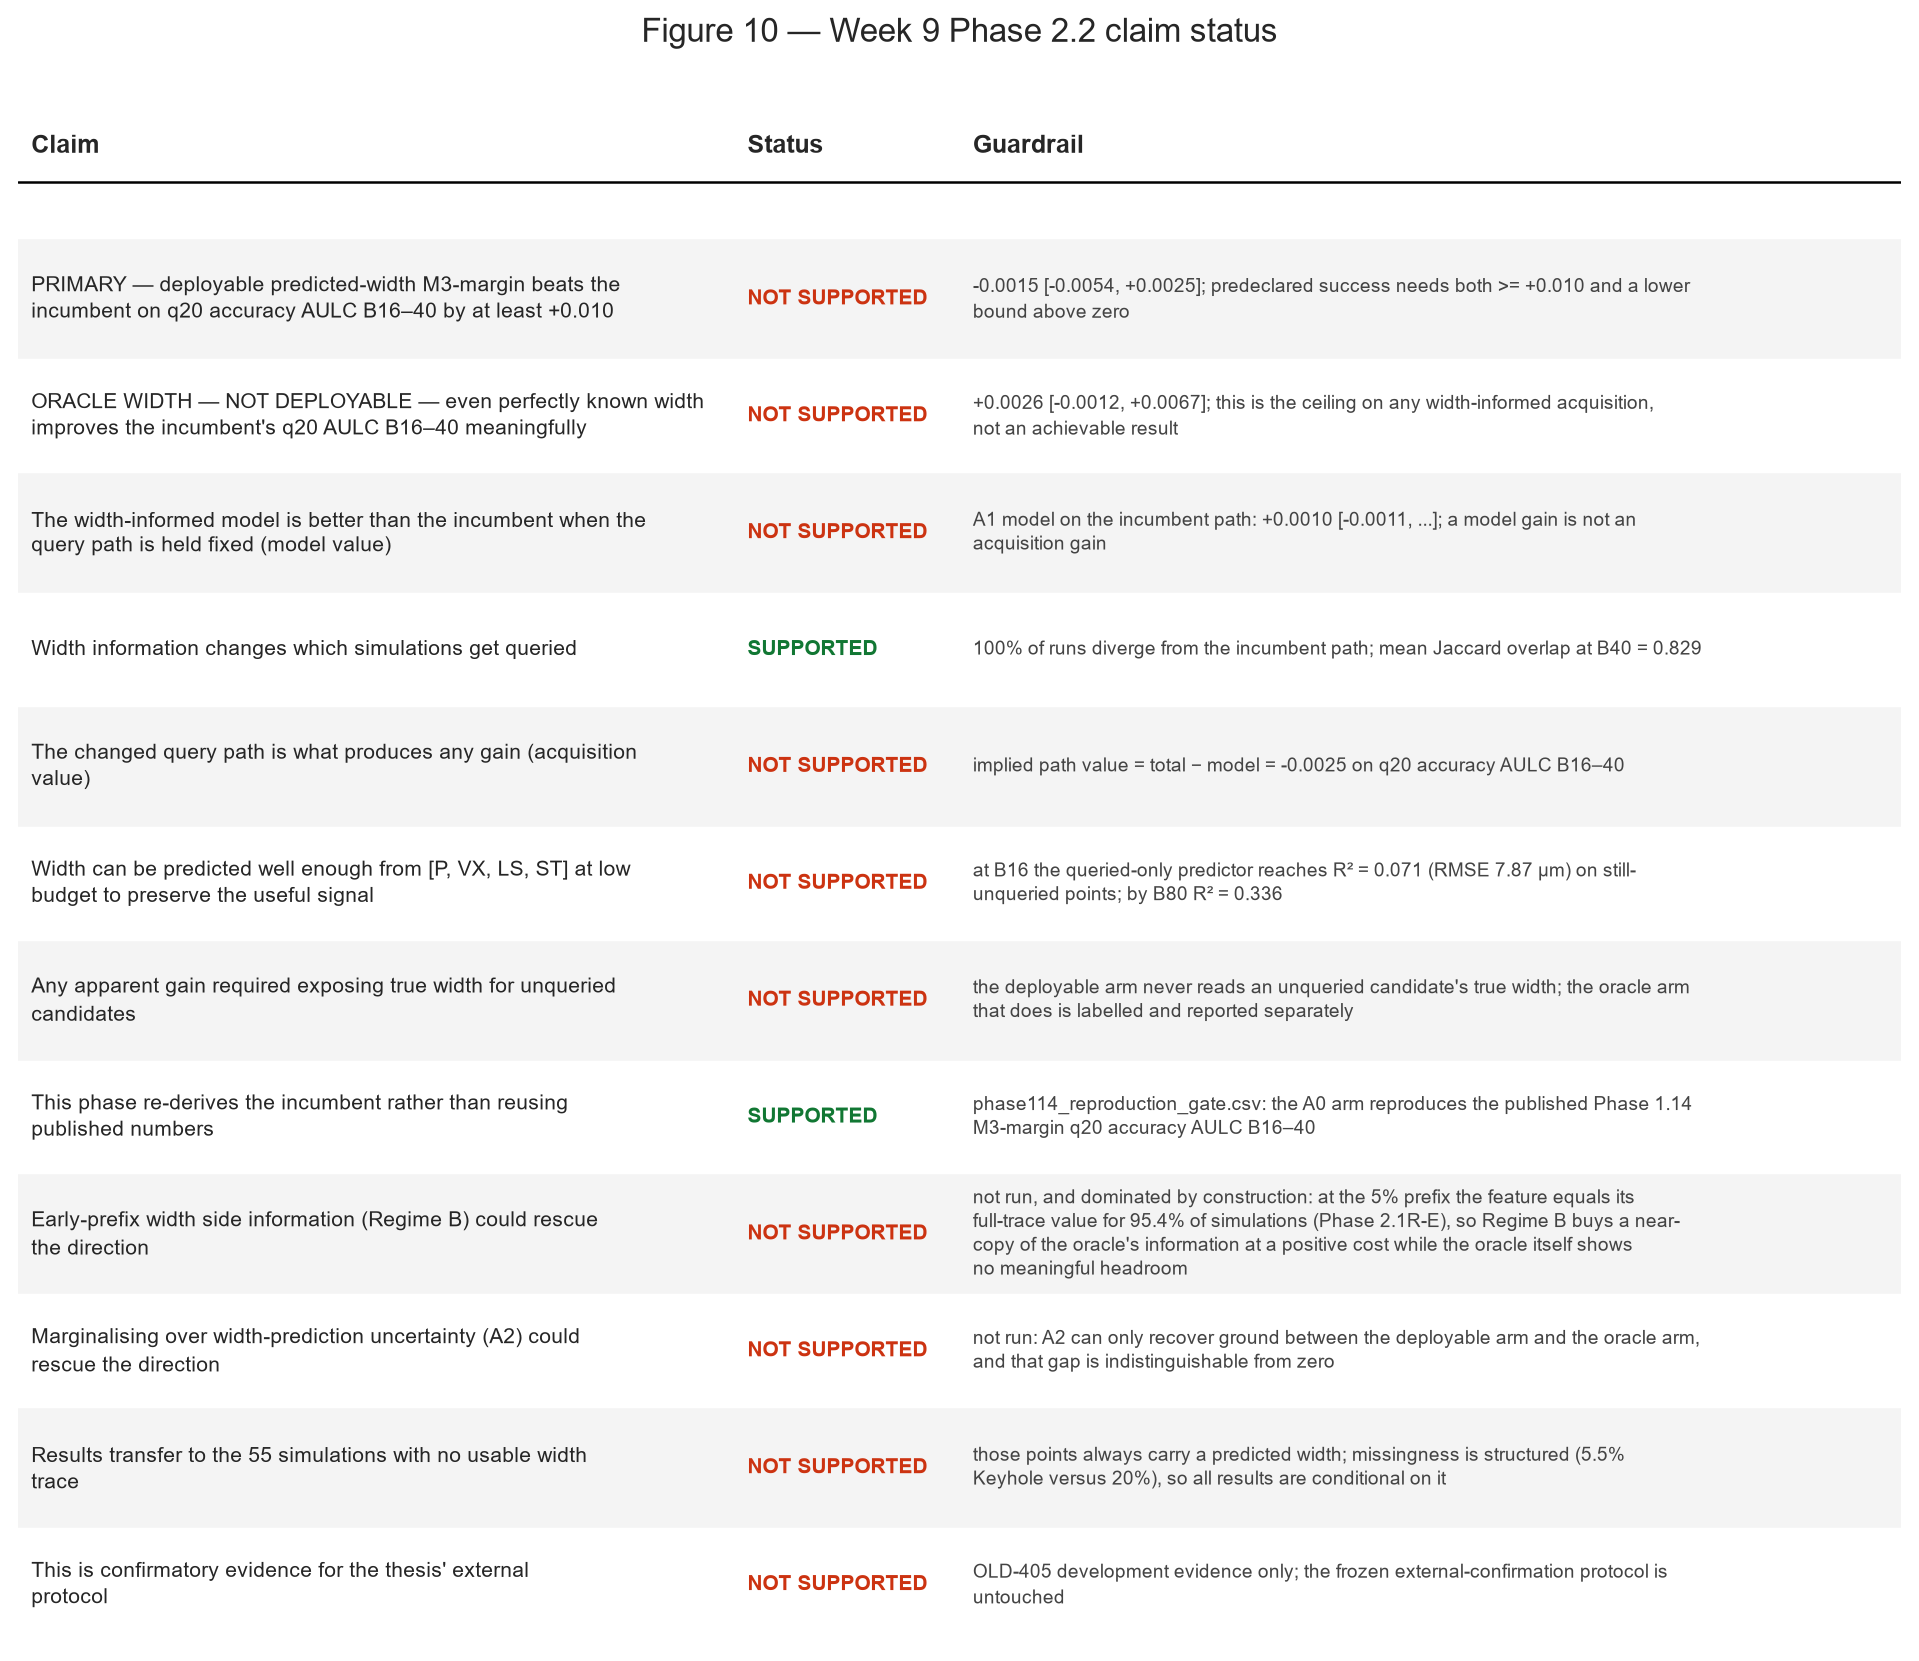

{
  "fraction_of_runs_with_a_different_path": 1.0,
  "keyhole_recall_change": -0.002065228174603184,
  "keyhole_recall_ci_lower": -0.010842609126984135,
  "model_only_ci_lower": -0.0011155024509804205,
  "model_only_gain": 0.0009926470588235204,
  "oracle_headroom": 0.0026225490196078614,
  "oracle_headroom_ci_lower": -0.0012380514705882513,
  "oracle_headroom_ci_upper": 0.006740502450980424,
  "path_jaccard_B40": 0.8290673338971832,
  "primary_gain": -0.0014950980392156865,
  "primary_gain_ci_lower": -0.005428921568627465,
  "primary_gain_ci_upper": 0.0025370710784313475,
  "success_criteria": {
    "gain_at_least_0.010": false,
    "keyhole_recall_not_materially_degraded": true,
    "model_value_positive_on_incumbent_path": false,
    "oracle_headroom_meaningful": false,
    "paired_ci_lower_above_zero": false
  },
  "verdict": "KILLED"
}


In [11]:
display(Image(filename=OUT/'figures'/'10_claim_status.png'))
print(json.dumps(json.loads((OUT/'decision.json').read_text(encoding='utf-8')), indent=2))
